## **Walkthrough for risk engine**
The goal of this notebook is to walk through the user of the repository capabilities and possibly understanding material. I will use my own portfolio as an example.

# *Setup*
We typically want to start our code with our import of packages, fro this partiocular repositary they have been defined withion the README

In [12]:
!pip install yfinance
!pip install PANDAS
!pip install numpy
!pip install pandas
!pip install statsmodels
!pip install arch

import numpy as np
import yfinance as yf
from scipy.stats import norm, t
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
from arch import arch_model
from arch.univariate import volatility
from scipy.stats import chi2

After downloading and importing the adequate libraries the USER is expected to clean their own data. The repositary assumes you can produce your own close prices in terms of a matrix, teher are many ways to perform this and we will show youa  simpel way as well as basi data cleaning needed for me to develop successful VaR.

In [77]:
#We can start by downlaoding all our stocks and getting all their CLose prices for the last 6 years
data = yf.download(["NDIA.L","ICGA.DE","IJPH.L","VUKG.L","VWRP.L","GAW.L","VUAG.L","UBI.PA","GGP.L","PAF.L","AMD"], period="8y")
#We want to drop all unknown values which there as we downlaoded straight from yf there shoudl not be but justa s a precaution.
close_data = data['Close'].dropna()

ndia_prices = np.array(close_data['NDIA.L'])
icga_prices = np.array(close_data['ICGA.DE'])
ijph_prices = np.array(close_data['IJPH.L'])
vukg_prices = np.array(close_data['VUKG.L'])
vwrp_prices = np.array(close_data['VWRP.L'])
gaw_prices  = np.array(close_data['GAW.L'])
vuag_prices = np.array(close_data['VUAG.L'])
ubi_prices  = np.array(close_data['UBI.PA'])
ggp_prices  = np.array(close_data['GGP.L'])
paf_prices  = np.array(close_data['PAF.L'])
amd_prices  = np.array(close_data['AMD'])

portfolio = []
portfolio.append(ndia_prices)
portfolio.append(icga_prices)
portfolio.append(ijph_prices)
portfolio.append(vukg_prices)
portfolio.append(vwrp_prices)
portfolio.append(gaw_prices)
portfolio.append(vuag_prices)
portfolio.append(ubi_prices)
portfolio.append(ggp_prices)
portfolio.append(paf_prices)
portfolio.append(amd_prices)

/tmp/ipykernel_1098/2536804454.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(["NDIA.L","ICGA.DE","IJPH.L","VUKG.L","VWRP.L","GAW.L","VUAG.L","UBI.PA","GGP.L","PAF.L","AMD"], period="8y")
[*********************100%***********************]  11 of 11 completed


With the data collected we can now combien our matrix intoa single vector this simplifies the linear algebra in terms of we only focus ona  1xD dimension. This allows us to bypasss the complexity of a covariance matrix and its asssumptions. As we are focusing on a multi-stock portoflio we weill eb using simpek, returns due to log returns lacking in deligation of weights.

In [78]:
#First we stack all our assets into a singel vector and define our weights
price_matrix = np.vstack(portfolio)
weight = np.array([18,17,15.59,14.15,13.95,8.98,8.63,1.39,1.19,0.72,0.4])
#The following code is optional and useful if you want to see how many closing prices you ahve and if number of assets is correct
#print(price_matrix.shape)

#We now run teh following code found in the repositary under risk_engine/utils.py
def portfolio_vec(weight, price_matrix):
    percent=(price_matrix[:, 1:] - price_matrix[:, :-1]) / price_matrix[:, :-1]
    port_vec = np.dot(weight,price_matrix)
    percent_vec = np.dot(weight,percent)
    return percent,port_vec, percent_vec

#We perform the fucntion and proceed with simple data cleaninga dn manipuation. I particular, we scale it by 100 and assign 0 an approximate value to asssist the GARCH Models.
percent,port_vec, percent_vec=portfolio_vec(weight, price_matrix)
percent_vec[percent_vec==0.0] =1e-8

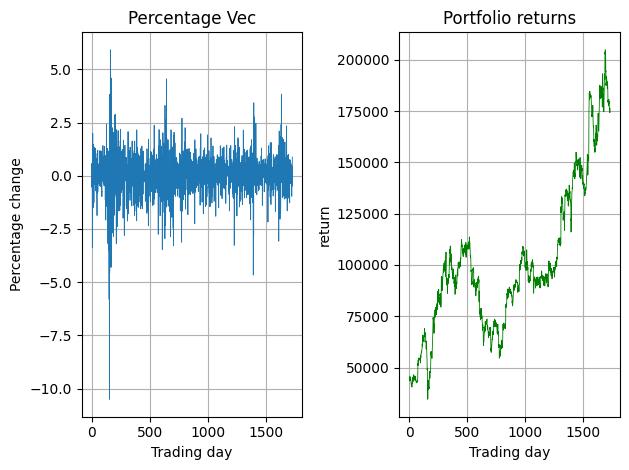

In [85]:
num= list(range(0, len(percent_vec)))
num2=list(range(0, len(port_vec)))
plt.subplot(1,2,1)
plt.plot(num,percent_vec,linewidth=0.6)
plt.title("Percentage Vec")
plt.xlabel("Trading day")
plt.ylabel("Percentage change")
plt.grid()
plt.subplot(1,2,2)
plt.plot(num2,port_vec,'g', linewidth=0.6)
plt.title("Portfolio returns")
plt.xlabel("Trading day")
plt.ylabel("return")
plt.grid()
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

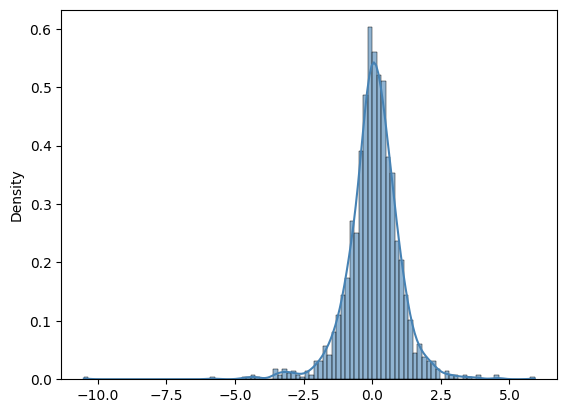

In [99]:
import seaborn as sns

sns.histplot(percent_vec, bins=100, kde=True, stat="density", color="steelblue", alpha=0.6)
plt.show

Once we have our portfolio vectors we must define our models found in risk_engine/models.py

In [22]:
def hist_risk(percent_vec,alpha):
  if len(percent_vec) <100:
    print(f"lack of data may lead to insufficient statistical reliability")
  w = np.sort(percent_vec)
  q = int(np.floor(alpha*len(percent_vec)))
  VaR = abs(w[q])

#move onto expected shortfall completing our historical risk fucntion
  E_SF = abs(np.mean(w[:q]))
  #print(f"The historical {alpha*100}% VaR for {len(percent_vec)} days is: {VaR}")
  #print(f"The historical {alpha*100}% Expected shortfall for {len(percent_vec)} days is: {E_SF}")
  return VaR, E_SF

def normal_riskp(alpha, percent_vec):
  #drift = np.mean(port_vec)
  sd = np.std(percent_vec)
  #sd =  np.sqrt(weight.T@np.cov(percent_vec, rowvar=True)@ weight)
  VaR = -sd*norm.ppf(alpha)

  #ES
  ES= sd*norm.pdf(norm.ppf(alpha))/alpha

  #print(f"The normal {alpha*100}% VaR for {percent_vec.shape[1]} days is: {VaR}")
  #print(f"The normal {alpha*100}% Expected shortfall for {percent_vec.shape[1]} days is: {ES}")
  return VaR, ES

def student_risk(alpha, percent_vec):
  mean=np.mean(percent_vec)
  avg_fourth = np.mean((percent_vec-mean)**4)
  std = np.std(percent_vec)**4
  E_kurtosis = avg_fourth/std
  kurtosis= E_kurtosis-3
  DF = (6/kurtosis)+4
  sd=np.std(percent_vec)
  #sd =  np.sqrt(weight.T@np.cov(percent_vec, rowvar=True)@ weight)
  VaR = -sd*t.ppf(alpha,DF)

  #ES
  ES = sd*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))
  #print(f"The t dist {alpha*100}% VaR for {percent_vec.shape[1]} days is: {VaR}")
  #print(f"The t dist {alpha*100}% Expected shortfall for {percent_vec.shape[1]} days is: {ES}")
  return VaR, ES

def findGARCH(percent_vec):
  model_candidates = [
      ("GARCH_model_N_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GARCH_model_N_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GARCH_model_N_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'normal', rescale = False)),
      ("GARCH_model_t_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=0, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("EGARCH_t", arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'StudentsT', rescale = False)),
      ("EGARCH_N", arch_model(percent_vec,mean = 'constant', lags=0, vol='EGARCH', p=1, q=1, o=1, dist = 'Normal', rescale = False)),
      ("TGARCH_model_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("TGARCH_model_N_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'normal', rescale = False)),
      ("TGARCH_model_t_2", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=2, q=1, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("TGARCH_model_N_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'normal', rescale = False)),
      ("TGARCH_model_t_3", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=2, o=1, power= 1.0, dist = 'StudentsT', rescale = False)),
      ("GJR_GARCH_t_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'StudentsT', rescale = False)),
      ("GJR_GARCH_N_1", arch_model(percent_vec,mean = 'constant', lags=0, vol = 'GARCH', p=1, q=1, o=1, power= 2.0, dist = 'Normal', rescale = False))
  ]
#bug fix to assist with cleaning data
  successful_fitted_models = {}
  for name, model_instance in model_candidates:
    try:
      res=model_instance.fit(disp='off')
      if res.optimization_result.success:
        successful_fitted_models[name] = res
      else:
        print(f"Model {name} failed to converge (status {res.optimization_result.status}:{res.optimization_result.message}). Disqualifying.")
    except Exception as e:
      print(f"An error occurred while fitting model {name}:{e}. Disqualifying.")
  if not successful_fitted_models:
      print("No GARCH models converged successfully")
      return None

  scoreS = {}
  for name, res in successful_fitted_models.items():
      ll = res.loglikelihood
      n = res.num_params
      AIC = 2 * n - 2 * ll
      BIC = n * np.log(len(percent_vec)) - 2 * ll
      scoreS[name] = {"AIC": AIC, "BIC": BIC}

  o_modelA = min(scoreS, key=lambda m: scoreS[m]["AIC"])
  o_modelB = min(scoreS, key=lambda m: scoreS[m]["BIC"])

  if o_modelA != o_modelB:
      print(f"AIC and BIC do not agree. AIC chose {o_modelA}, BIC chose {o_modelB}. Using BIC's choice as it's stricter.")
      chosen_model = o_modelB
  else:
    print(f"AIC and BIC agree, choosing {o_modelA}")
    chosen_model = o_modelA

  return successful_fitted_models[chosen_model]


def compute_garch_risk(o_model, alpha, window):
    current_o_model = o_model
    try:
        from arch.univariate import EGARCH
        if isinstance(current_o_model.model.volatility, EGARCH):
            vol_str = 'EGARCH'
        else:
            vol_str = 'GARCH'
    except ImportError:
        vol_str = 'GARCH'

    dist_name_from_model = current_o_model.model.distribution.name
    if dist_name_from_model == "Normal":
        dist_arg = "normal"
    elif dist_name_from_model in ["StudentT", "Standardized Student's t"]:
        dist_arg = "studentst"
    else:
        dist_arg = dist_name_from_model.lower()

    power_val = getattr(current_o_model.model.volatility, 'power', 2.0)
    p_val = current_o_model.model.volatility.p
    q_val = current_o_model.model.volatility.q
    o_val = getattr(current_o_model.model.volatility, 'o', 0)

    Model = arch_model(window, mean='constant', lags=0, vol=vol_str, p=p_val, q=q_val, o=o_val, power=power_val, dist=dist_arg, rescale=False)
    res = Model.fit(disp='off')
  #DF = res.params['nu']
    forecasts = res.forecast()
    f_v=forecasts.variance.iloc[-1,0]
    f_SD =np.sqrt(f_v)
  #VaR_N= f_SD*norm.ppf(alpha)*value
  #VaR_t=f_SD*t.ppf(alpha,DF)*value
  #VaR_N_over_days = VaR_N*np.sqrt(T)
  #VaR_t_over_days = VaR_t*np.sqrt(T)

  #ES
  #ES_t = f_SD*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))*value
  #ES_N= -*f_SD*norm.pdf(norm.ppf(alpha))/alpha *value
  #Now consider multio day VaR
  #ES_t_over_days = ES_t *np.sqrt(T)
  #ES_N_over_days =ES_N * np.sqrt(T)


    if 'nu' in res.params:
      DF = res.params['nu']
      VaR_t=-f_SD*t.ppf(alpha,DF)
      VaR_t_over_days = VaR_t
      ES_t = f_SD*(t.pdf(t.ppf(alpha,DF),DF)/alpha)*((DF+ t.ppf(alpha,DF)**2)/(DF-1))
      ES_t_over_days = ES_t
      return VaR_t_over_days, ES_t_over_days, res

    else:
      VaR_N= -f_SD*norm.ppf(alpha)
      VaR_N_over_days = VaR_N
      ES_N= f_SD*norm.pdf(norm.ppf(alpha))/alpha
      ES_N_over_days =ES_N
      return VaR_N_over_days,ES_N_over_days, res


  #return VaR_N_over_days,VaR_t_over_days,ES_t_over_days,ES_N_over_days

Now we can define our backtesting and hypothesis test from risk_engine/backtester.py and risk_engine/hypothesis_tests.py

In [23]:
#https://tutorialreference.com/python/examples/faq/python-how-to-find-index-of-element-of-list-that-meet-a-condition
#def first_drop_point(data_list, threshold):
 #   sorted_list = sorted(data_list)
 #   for idx, value in enumerate(sorted_list):
  #      if value < threshold:
  #          return idx
  #  return None

def first_drop_point(data_list, threshold):
    sorted_list = sorted(data_list)
    for idx, value in enumerate(sorted_list):
        if value > threshold:
            return idx
    return len(sorted_list)
def ES_error(values, ES_val):
  sort_val = np.sort(values)

  n_H = first_drop_point(values, ES_val)
  below_vals = sort_val[:n_H]
  k_H = np.mean(below_vals)
  E_H = abs(k_H) - abs(ES_val)
  return E_H

def backtest(hist_percent_vec, BURNIN,alpha):
  ASSIST_FINDGARCH = hist_percent_vec[0:BURNIN]
  o_model=findGARCH(ASSIST_FINDGARCH)
  di = {"Date": [],
        "Simple_return": [],
        "N_breachoVaR": [],
        "T_breachoVaR": [],
        "H_breachoVaR": [],
        "G_breachoVaR": [],
        "N_ES": [],
        "T_ES": [],
        "H_ES": [],
        "G_ES": [],
        "N_VaR":[],
        "T_VaR":[],
        "H_VaR":[],
        "G_VaR":[],
        }

  BR_H=[]
  BR_N=[]
  BR_T=[]
  BR_G=[]
  ES_E_H=[]
  ES_E_N=[]
  ES_E_T=[]
  ES_E_G=[]
  for t in range(BURNIN,len(hist_percent_vec)):
    backtest_t = t - BURNIN
    t1=t-BURNIN
    t2 =t
    window =hist_percent_vec[t1:t2]
    di["Simple_return"].append(hist_percent_vec[t])
    di["Date"].append(t)


    H_VaR, H_E_SF=hist_risk(window,alpha)
    di["H_VaR"].append(H_VaR)
    di["H_ES"].append(H_E_SF)
    if hist_percent_vec[t] <-H_VaR:
      di["H_breachoVaR"].append(1)
    else:
      di["H_breachoVaR"].append(0)

    N_VaR, N_E_SF=normal_riskp(alpha,window)
    di["N_VaR"].append(N_VaR)
    di["N_ES"].append(N_E_SF)
    if hist_percent_vec[t] <-N_VaR:
      di["N_breachoVaR"].append(1)
    else:
      di["N_breachoVaR"].append(0)

    t_VaR, t_E_SF=student_risk(alpha, window)
    di["T_VaR"].append(t_VaR)
    di["T_ES"].append(t_E_SF)
    if hist_percent_vec[t] <-t_VaR:
      di["T_breachoVaR"].append(1)
    else:
      di["T_breachoVaR"].append(0)



    G_VaR, G_E_SF, o_model=compute_garch_risk(o_model, alpha,window)
    di["G_VaR"].append(G_VaR)
    di["G_ES"].append(G_E_SF)
    if hist_percent_vec[t] <-G_VaR:
      di["G_breachoVaR"].append(1)
    else:
      di["G_breachoVaR"].append(0)

    if backtest_t >= 100:
      values = hist_percent_vec[t-BURNIN:t]
      total_D =len(di["H_breachoVaR"])
      #Historical
      H_ES=di["H_ES"][-1]
      ES_E_H.append(ES_error(values, H_ES))
      BR_H.append(sum(di["H_breachoVaR"])/total_D)

      #Normal
      N_ES=di["N_ES"][-1]
      ES_E_N.append(ES_error(values, N_ES))
      BR_N.append(sum(di["N_breachoVaR"])/total_D)
      #Student
      T_ES=di["T_ES"][-1]
      ES_E_T.append(ES_error(values, T_ES))
      BR_T.append(sum(di["T_breachoVaR"])/total_D)
      #GARCH
      G_ES=di["G_ES"][-1]
      ES_E_G.append(ES_error(values, G_ES))
      BR_G.append(sum(di["G_breachoVaR"])/total_D)

  return ES_E_H,ES_E_N,ES_E_T,ES_E_G,BR_H,BR_N,BR_T,BR_G,di

We can now run our backtest to see which model is optimum and see how well our models run, I suggest altering BURNIN depending on the numner of tarding days you have.

AIC and BIC agree, choosing TGARCH_model_t_1


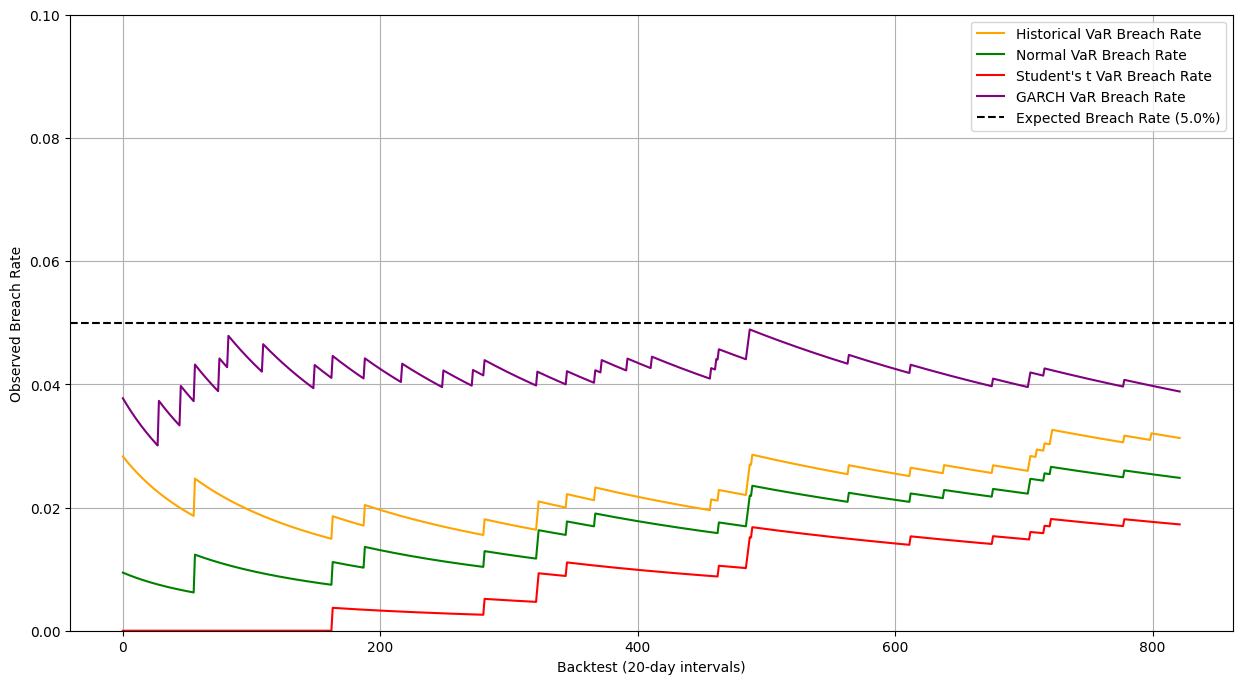

In [48]:
percent_vec=percent_vec*100
percent,port_vec, percent_vec =portfolio_vec(weight, price_matrix)
percent_vec=percent_vec*100

BURNIN=800
alpha=0.05

ES_E_H, ES_E_N, ES_E_T, ES_E_G, BR_H, BR_N, BR_T, BR_G, di = backtest(percent_vec, BURNIN, alpha)

plt.figure(figsize=(15, 8))

plt.plot(BR_H[5:], label='Historical VaR Breach Rate', color='orange')
plt.plot(BR_N[5:], label='Normal VaR Breach Rate', color='green')
plt.plot(BR_T[5:], label="Student's t VaR Breach Rate", color='red')
plt.plot(BR_G[5:], label='GARCH VaR Breach Rate', color='purple')

plt.axhline(y=alpha, color='black',linestyle='--', label=f"Expected Breach Rate ({alpha*100}%)")

plt.ylim(0, 0.1)

plt.xlabel('Backtest (20-day intervals)')
plt.ylabel('Observed Breach Rate')
plt.legend()
plt.grid()
plt.show()

In [49]:
#t=trading days, B= number of breaches and p=probability
def POF_test(t,B,alpha1,alpha2):
  df=1
  obs_rate = B/t
  #under null
  L0=((1-alpha1)**(t-B))*alpha1**B
  #under alternative
  L1=((1-obs_rate)**(t-B))*obs_rate**B

  t_stat = -2*np.log(L0/L1)
  critical_value = chi2.ppf(1 - alpha2, df)
  p_value = 1 - chi2.cdf(t_stat, df=1)
  if t_stat>=critical_value:
    print(f"refect H0 and accept H1")
  else:
    print(f"Do not reject H0")
  return p_value

#B is number of breaches
def CIT(B,alpha):
  #check yesterday and today for transition matrix
  k=np.array(B)
  n00= sum((k[:-1]==0) & (k[1:]==0))
  n01 = sum((k[:-1]==0) & (k[1:]==1))
  n10 = sum((k[:-1]==1) & (k[1:]==0))
  n11=sum((k[:-1]==1) & (k[1:]==1))

  t_matrix = np.array([[n00,n01],
                       [n10,n11]])

  o_b_prob=(n01+n11)/(n00+n01+n10+n11)
  b_prob_n_b_y =n01/(n00+n01)
  b_prob_b_y =n11/(n10+n11)

  #under null
  L0 = (1-o_b_prob)**(n00+n10)*o_b_prob**(n01+n11)
  #under alternate
  L1= ((1-b_prob_n_b_y)**n00)*(b_prob_n_b_y**n01)*((1-b_prob_b_y)**n10)*b_prob_b_y**n11

  Test_stat=-2*np.log(L0/L1)
  critical_value = chi2.ppf(1 - alpha, df=1)
  p_value = 1 - chi2.cdf(Test_stat, df=1)

  if Test_stat>=critical_value:
    print(f"refect H0 and accept H1")
  else:
    print(f"Do not reject H0")
  return p_value


In [50]:
alpha_ht = 0.05
t_obs = len(di["H_breachoVaR"])

print(f"\nPOF Test (alpha_ht={alpha_ht})")

B_H = sum(di["H_breachoVaR"])
p_value_H_pof = POF_test(t_obs, B_H, alpha, alpha_ht)
print(f"Historical VaR POF Test:p-value={p_value_H_pof:.4f}")

B_N = sum(di["N_breachoVaR"])
p_value_N_pof = POF_test(t_obs, B_N, alpha, alpha_ht)
print(f"Normal VaR POF Test:p-value={p_value_N_pof:.4f}")

B_T = sum(di["T_breachoVaR"])
p_value_T_pof = POF_test(t_obs, B_T, alpha, alpha_ht)
print(f"Student's t VaR POF Test:p-value={p_value_T_pof:.4f}")

B_G = sum(di["G_breachoVaR"])
p_value_G_pof = POF_test(t_obs, B_G, alpha, alpha_ht)
print(f"GARCH VaR POF Test:p-value={p_value_G_pof:.4f}")
print(f"\n")
print(f"CIT Test (alpha_ht={alpha_ht})")

p_value_H_cit = CIT(di["H_breachoVaR"], alpha_ht)
print(f"Historical VaR CIT Test: p-value={p_value_H_cit:.4f}")

p_value_N_cit = CIT(di["N_breachoVaR"], alpha_ht)
print(f"Normal VaR CIT Test: p-value={p_value_N_cit:.4f}")

p_value_T_cit = CIT(di["T_breachoVaR"], alpha_ht)
print(f"Student's t VaR CIT Test: p-value={p_value_T_cit:.4f}")

p_value_G_cit = CIT(di["G_breachoVaR"], alpha_ht)
print(f"GARCH VaR CIT Test: p-value={p_value_G_cit:.4f}")


POF Test (alpha_ht=0.05)
refect H0 and accept H1
Historical VaR POF Test:p-value=0.0051
refect H0 and accept H1
Normal VaR POF Test:p-value=0.0001
refect H0 and accept H1
Student's t VaR POF Test:p-value=0.0000
Do not reject H0
GARCH VaR POF Test:p-value=0.1051


CIT Test (alpha_ht=0.05)
refect H0 and accept H1
Historical VaR CIT Test: p-value=0.0014
refect H0 and accept H1
Normal VaR CIT Test: p-value=0.0017
refect H0 and accept H1
Student's t VaR CIT Test: p-value=0.0017
Do not reject H0
GARCH VaR CIT Test: p-value=0.2165
